In [5]:
import os
from pathlib import Path

# Detect runtime environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Set project root based on environment
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/qsar-esol-solubility')
else:
    PROJECT_ROOT = Path.cwd().parent

# Derived paths
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

# Create directories if missing
for d in [RAW_DIR, PROCESSED_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Models dir: {MODELS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Colab
Project root: /content/drive/MyDrive/qsar-esol-solubility
Models dir: /content/drive/MyDrive/qsar-esol-solubility/models


In [6]:
!pip install rdkit deepchem -q

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [7]:
df = pd.read_csv(PROCESSED_DIR / 'esol_dedup.csv')
print(f"Loaded {len(df)} molecules")
print(f"Columns: {list(df.columns)}")

# Rebuild RDKit Mol objects (not serialized in CSV)
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

# Sanity check: any failed parses?
n_failed = df['mol'].isna().sum()
assert n_failed == 0, f"{n_failed} SMILES failed to parse"
print("All SMILES parsed correctly.")

df.head()

Loaded 1117 molecules
Columns: ['smiles', 'logS']
All SMILES parsed correctly.


,smiles,logS,mol
0,BrC(Br)(Br)Br,-3.14,<rdkit.Chem.rdchem.Mol object at 0x7baca2302c00>
1,BrC(Br)Br,-1.91,<rdkit.Chem.rdchem.Mol object at 0x7baca2301af0>
2,BrCBr,-1.17,<rdkit.Chem.rdchem.Mol object at 0x7baca2303ed0>
3,BrCCBr,-1.68,<rdkit.Chem.rdchem.Mol object at 0x7baca23037d0>
4,Brc1cc(Br)c(Br)cc1Br,-6.98,<rdkit.Chem.rdchem.Mol object at 0x7baca23028f0>


In [8]:
print(df['logS'].describe())
print(f"\nExpected: count=1117, mean≈-3.05, std≈2.10, min≈-11.6, max≈+1.58")

count    1117.000000
mean       -3.050058
std         2.095457
min       -11.600000
25%        -4.310000
50%        -2.863000
75%        -1.600000
max         1.580000
Name: logS, dtype: float64

Expected: count=1117, mean≈-3.05, std≈2.10, min≈-11.6, max≈+1.58


In [9]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict


def get_scaffold(mol, include_chirality=False):
    """
    Compute the Bemis-Murcko scaffold of a molecule as a canonical SMILES string.

    The Bemis-Murcko scaffold is the molecular skeleton obtained by removing
    side-chain atoms while keeping all ring systems and the linkers between them.
    Reference: Bemis & Murcko, J. Med. Chem. 1996, 39, 2887-2893.
    """
    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=include_chirality
    )


def scaffold_split(df, mol_col='mol',
                   train_frac=0.8, valid_frac=0.1, test_frac=0.1):
    """
    Deterministic scaffold split.

    Molecules are grouped by Bemis-Murcko scaffold; groups are sorted by
    decreasing size and assigned to train, valid, test in turn so that
    the most populated scaffolds end up in train and rare scaffolds in test.
    This produces a harder, more realistic generalization metric than
    random splitting.

    Returns three lists of dataframe indices.
    """
    assert abs(train_frac + valid_frac + test_frac - 1.0) < 1e-6

    # 1. Group dataframe indices by scaffold
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaffold = get_scaffold(row[mol_col])
        scaffolds[scaffold].append(idx)

    # 2. Sort scaffold groups by size (descending), with scaffold string as tiebreaker
    scaffold_groups = sorted(
        scaffolds.values(),
        key=lambda group: (len(group), group[0]),
        reverse=True
    )

    # 3. Assign groups to splits in order
    n_total = len(df)
    n_train_target = int(train_frac * n_total)
    n_valid_target = int(valid_frac * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        elif len(valid_idx) + len(group) <= n_valid_target:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)

    return train_idx, valid_idx, test_idx

In [10]:
train_idx, valid_idx, test_idx = scaffold_split(df)

print("Split sizes:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"  Valid: {len(valid_idx)} ({len(valid_idx)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)")
print(f"  Total: {len(train_idx)+len(valid_idx)+len(test_idx)} (expected {len(df)})")

# Materialize the three splits as dataframes
df_train = df.loc[train_idx].reset_index(drop=True)
df_valid = df.loc[valid_idx].reset_index(drop=True)
df_test  = df.loc[test_idx].reset_index(drop=True)

# === Sanity check 1: scaffolds must be disjoint across splits ===
def scaffolds_in(d):
    return set(d['mol'].apply(get_scaffold))

scaf_train = scaffolds_in(df_train)
scaf_valid = scaffolds_in(df_valid)
scaf_test  = scaffolds_in(df_test)

overlap_tv = scaf_train & scaf_valid
overlap_tt = scaf_train & scaf_test
overlap_vt = scaf_valid & scaf_test

print(f"\nScaffold overlap (must all be 0):")
print(f"  Train ∩ Valid: {len(overlap_tv)}")
print(f"  Train ∩ Test:  {len(overlap_tt)}")
print(f"  Valid ∩ Test:  {len(overlap_vt)}")

assert len(overlap_tv) == 0, "Scaffold leak between train and valid!"
assert len(overlap_tt) == 0, "Scaffold leak between train and test!"
assert len(overlap_vt) == 0, "Scaffold leak between valid and test!"

# === Sanity check 2: target distribution similarity ===
print(f"\nTarget distribution per split:")
print(f"  Train: μ={df_train['logS'].mean():+.3f}, σ={df_train['logS'].std():.3f}")
print(f"  Valid: μ={df_valid['logS'].mean():+.3f}, σ={df_valid['logS'].std():.3f}")
print(f"  Test:  μ={df_test['logS'].mean():+.3f}, σ={df_test['logS'].std():.3f}")

Split sizes:
  Train: 893 (79.9%)
  Valid: 111 (9.9%)
  Test:  113 (10.1%)
  Total: 1117 (expected 1117)

Scaffold overlap (must all be 0):
  Train ∩ Valid: 0
  Train ∩ Test:  0
  Valid ∩ Test:  0

Target distribution per split:
  Train: μ=-2.872, σ=2.073
  Valid: μ=-3.671, σ=2.323
  Test:  μ=-3.845, σ=1.719


In [11]:
from rdkit.Chem import AllChem
from rdkit import DataStructs


def morgan_fingerprint(mol, radius=2, n_bits=2048):
    """
    Compute Morgan/ECFP fingerprint as a NumPy array of int8.

    Morgan fingerprints encode local atom environments up to `radius` bonds away
    by hashing each substructure into a fixed-length bit vector.
    Reference: Rogers & Hahn, J. Chem. Inf. Model. 2010, 50, 742-754.
    """
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def featurize_morgan(df, mol_col='mol', radius=2, n_bits=2048):
    """Stack Morgan fingerprints for all molecules in a dataframe."""
    fps = np.stack([morgan_fingerprint(m, radius, n_bits) for m in df[mol_col]])
    return fps

In [12]:
X_train = featurize_morgan(df_train)
X_valid = featurize_morgan(df_valid)
X_test  = featurize_morgan(df_test)

y_train = df_train['logS'].values
y_valid = df_valid['logS'].values
y_test  = df_test['logS'].values

print(f"X_train: {X_train.shape}, dtype={X_train.dtype}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test:  {X_test.shape}")

# Sanity checks on the feature matrix
print(f"\nMean bits set per molecule (train): {X_train.sum(axis=1).mean():.1f} / {X_train.shape[1]}")
print(f"Sparsity (train): {1 - X_train.mean():.3f}")
print(f"NaNs anywhere: {np.isnan(X_train).any() or np.isnan(X_valid).any() or np.isnan(X_test).any()}")

X_train: (893, 2048), dtype=int8
X_valid: (111, 2048)
X_test:  (113, 2048)

Mean bits set per molecule (train): 19.4 / 2048
Sparsity (train): 0.991
NaNs anywhere: False


In [13]:
# Diagnostic: bits set vs molecule size
n_atoms_train = df_train['mol'].apply(lambda m: m.GetNumAtoms()).values
bits_set_train = X_train.sum(axis=1)

print(f"Atoms per molecule (train):")
print(f"  min={n_atoms_train.min()}, median={int(np.median(n_atoms_train))}, max={n_atoms_train.max()}")

# Bin molecules by size and show average bits set
bins = [0, 10, 20, 30, 50, 200]
for low, high in zip(bins[:-1], bins[1:]):
    mask = (n_atoms_train >= low) & (n_atoms_train < high)
    if mask.sum() > 0:
        avg_bits = bits_set_train[mask].mean()
        print(f"  {low:3d}-{high:3d} atoms: {mask.sum():3d} molecules, avg bits set = {avg_bits:.1f}")

Atoms per molecule (train):
  min=1, median=11, max=34
    0- 10 atoms: 385 molecules, avg bits set = 11.6
   10- 20 atoms: 394 molecules, avg bits set = 21.5
   20- 30 atoms: 109 molecules, avg bits set = 38.0
   30- 50 atoms:   5 molecules, avg bits set = 56.4


Note on dataset chemistry. ESOL covers a wide range of molecule sizes (1–34 heavy atoms in train), with the vast majority below 20 atoms. Models trained here will see few large molecules and may struggle on out-of-distribution test cases.

In [14]:
from sklearn.ensemble import RandomForestRegressor
import time

rf_phase1 = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',     # standard for high-dim sparse fingerprints
    min_samples_leaf=1,
    n_jobs=-1,                # use all CPU cores on Colab
    random_state=RANDOM_SEED
)

start = time.time()
rf_phase1.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Random Forest (Phase 1: Morgan FP only)")
print(f"  Trees:           {rf_phase1.n_estimators}")
print(f"  Max features:    {rf_phase1.max_features}")
print(f"  Training time:   {elapsed:.1f}s")

Random Forest (Phase 1: Morgan FP only)
  Trees:           500
  Max features:    sqrt
  Training time:   6.3s


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate(model, X, y, split_name):
    """Compute RMSE / MAE / R² and return a dict."""
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    return {
        'split': split_name,
        'RMSE': rmse,
        'MAE':  mae,
        'R2':   r2,
        'y_true': y,
        'y_pred': y_pred
    }


# Evaluate on all three splits
results_p1 = {
    'train': evaluate(rf_phase1, X_train, y_train, 'train'),
    'valid': evaluate(rf_phase1, X_valid, y_valid, 'valid'),
    'test':  evaluate(rf_phase1, X_test,  y_test,  'test')
}

# Print metrics table
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, res in results_p1.items():
    print(f"{name:<8} {res['RMSE']:>7.3f} {res['MAE']:>7.3f} {res['R2']:>7.3f}")

# Reference benchmarks from literature
print(f"\nLiterature reference for ESOL scaffold split:")
print(f"  RF on Morgan FP: RMSE ≈ 1.05 - 1.15")

Split       RMSE     MAE      R²
--------------------------------
train      0.480   0.329   0.946
valid      1.703   1.325   0.458
test       1.553   1.176   0.177

Literature reference for ESOL scaffold split:
  RF on Morgan FP: RMSE ≈ 1.05 - 1.15


In [16]:
from rdkit.Chem import Descriptors, Crippen

# 1. Distribution MW and LogP
def stats(d, label):
    mw   = d['mol'].apply(Descriptors.MolWt).values
    logp = d['mol'].apply(Crippen.MolLogP).values
    print(f"{label:<8} MW: μ={mw.mean():>6.1f}, σ={mw.std():>5.1f}  "
          f"LogP: μ={logp.mean():>+5.2f}, σ={logp.std():>4.2f}  "
          f"logS: μ={d['logS'].mean():>+5.2f}, σ={d['logS'].std():>4.2f}")

print("Distribution:")
stats(df_train, 'Train')
stats(df_valid, 'Valid')
stats(df_test,  'Test')

# 2. Sanity check test
print(f"\nModel prediction on test set:")
y_pred_test = rf_phase1.predict(X_test)
print(f"  μ_pred = {y_pred_test.mean():+.3f}, μ_true = {y_test.mean():+.3f}")
print(f"  σ_pred = {y_pred_test.std():.3f},  σ_true = {y_test.std():.3f}")

# 3. Check errors
residuals = y_test - y_pred_test
worst_idx = np.argsort(np.abs(residuals))[-5:][::-1]
print(f"\nTop 5 worst predictions on test:")
for i in worst_idx:
    print(f"  smiles='{df_test.iloc[i]['smiles']}'  "
          f"true={y_test[i]:+.2f}  pred={y_pred_test[i]:+.2f}  "
          f"residual={residuals[i]:+.2f}")

Distribution:
Train    MW: μ= 187.4, σ= 93.9  LogP: μ=+2.45, σ=1.70  logS: μ=-2.87, σ=2.07
Valid    MW: μ= 247.3, σ=119.1  LogP: μ=+2.23, σ=2.58  logS: μ=-3.67, σ=2.32
Test     MW: μ= 289.6, σ= 98.8  LogP: μ=+2.74, σ=2.02  logS: μ=-3.85, σ=1.72

Model prediction on test set:
  μ_pred = -3.107, μ_true = -3.845
  σ_pred = 0.919,  σ_true = 1.711

Top 5 worst predictions on test:
  smiles='ClC1(Cl)C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(Cl)C5(Cl)C24Cl'  true=-6.80  pred=-2.05  residual=-4.75
  smiles='CCOc1ccc(C(C)(C)COCc2cccc(Oc3ccccc3)c2)cc1'  true=-8.60  pred=-3.94  residual=-4.66
  smiles='ClC(Cl)=C(c1ccc(Cl)cc1)c1ccc(Cl)cc1'  true=-6.90  pred=-3.05  residual=-3.85
  smiles='CC=C(C(=CC)c1ccc(O)cc1)c1ccc(O)cc1'  true=-4.95  pred=-1.20  residual=-3.75
  smiles='CC1COC2CC3(C)C(CC4C5C=C6CC(O)CCC6(C)CC5CCC43C)OC2C1'  true=-7.32  pred=-3.70  residual=-3.62


**Phase 1bis **—** Balanced scaffold split (ChemProp-style)**
The pure scaffold split above produced a pathological train/test partition: test molecules are systematically larger (MW ~290 vs ~187 in train) and more hydrophobic, leading to severe out-of-distribution prediction (test R² = 0.18 vs literature ~0.65).
The fix used in the literature (ChemProp, DeepChem) keeps large scaffold groups in train (so test contains genuinely novel scaffolds), but randomizes the assignment of singleton scaffolds (groups of size 1) across train/valid/test. This preserves the rigor of scaffold-based generalization while producing more representative splits.

In [17]:
import random


def scaffold_split_balanced(df, mol_col='mol',
                            train_frac=0.8, valid_frac=0.1, test_frac=0.1,
                            seed=42):
    """
    Balanced scaffold split (ChemProp-style).

    Large scaffold groups (size > 1) are sorted by size and assigned
    deterministically: largest groups go to train, ensuring rare scaffolds
    end up in test. Singleton scaffolds (size 1) are then shuffled with
    a fixed seed and distributed across the three splits to avoid the
    pathological case where all rare and structurally unusual molecules
    cluster in test.

    Returns three lists of dataframe indices.
    """
    assert abs(train_frac + valid_frac + test_frac - 1.0) < 1e-6

    # 1. Group dataframe indices by scaffold
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaffold = get_scaffold(row[mol_col])
        scaffolds[scaffold].append(idx)

    # 2. Separate large groups from singletons
    big_groups       = [g for g in scaffolds.values() if len(g) > 1]
    singleton_groups = [g for g in scaffolds.values() if len(g) == 1]

    # 3. Sort big groups by size (descending), shuffle singletons with fixed seed
    big_groups.sort(key=lambda g: (len(g), g[0]), reverse=True)
    rng = random.Random(seed)
    rng.shuffle(singleton_groups)

    # 4. Assign in order: big groups first (favor train), then shuffled singletons
    ordered_groups = big_groups + singleton_groups

    n_total = len(df)
    n_train_target = int(train_frac * n_total)
    n_valid_target = int(valid_frac * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in ordered_groups:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        elif len(valid_idx) + len(group) <= n_valid_target:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)

    return train_idx, valid_idx, test_idx

In [18]:
train_idx_b, valid_idx_b, test_idx_b = scaffold_split_balanced(df, seed=RANDOM_SEED)

print("Balanced split sizes:")
print(f"  Train: {len(train_idx_b)} ({len(train_idx_b)/len(df)*100:.1f}%)")
print(f"  Valid: {len(valid_idx_b)} ({len(valid_idx_b)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_idx_b)} ({len(test_idx_b)/len(df)*100:.1f}%)")

df_train_b = df.loc[train_idx_b].reset_index(drop=True)
df_valid_b = df.loc[valid_idx_b].reset_index(drop=True)
df_test_b  = df.loc[test_idx_b].reset_index(drop=True)

# Sanity check: scaffolds disjoint across splits
scaf_train_b = scaffolds_in(df_train_b)
scaf_valid_b = scaffolds_in(df_valid_b)
scaf_test_b  = scaffolds_in(df_test_b)
assert len(scaf_train_b & scaf_valid_b) == 0, "Scaffold leak train ↔ valid"
assert len(scaf_train_b & scaf_test_b)  == 0, "Scaffold leak train ↔ test"
assert len(scaf_valid_b & scaf_test_b)  == 0, "Scaffold leak valid ↔ test"
print("All scaffold-disjointness checks passed.")

# Distribution comparison: pure scaffold split vs balanced
def stats(d, label):
    mw   = d['mol'].apply(Descriptors.MolWt).values
    logp = d['mol'].apply(Crippen.MolLogP).values
    return f"{label:<14} MW: μ={mw.mean():>6.1f}  LogP: μ={logp.mean():>+5.2f}  logS: μ={d['logS'].mean():>+5.2f}, σ={d['logS'].std():>4.2f}"

print("\nDistribution per split (balanced):")
print(stats(df_train_b, 'Train (bal.)'))
print(stats(df_valid_b, 'Valid (bal.)'))
print(stats(df_test_b,  'Test  (bal.)'))

Balanced split sizes:
  Train: 893 (79.9%)
  Valid: 111 (9.9%)
  Test:  113 (10.1%)
All scaffold-disjointness checks passed.

Distribution per split (balanced):
Train (bal.)   MW: μ= 187.4  LogP: μ=+2.44  logS: μ=-2.87, σ=2.07
Valid (bal.)   MW: μ= 267.1  LogP: μ=+2.36  logS: μ=-3.58, σ=2.16
Test  (bal.)   MW: μ= 270.4  LogP: μ=+2.63  logS: μ=-3.93, σ=1.91


In [19]:
# Featurize with balanced split
X_train_b = featurize_morgan(df_train_b)
X_valid_b = featurize_morgan(df_valid_b)
X_test_b  = featurize_morgan(df_test_b)

y_train_b = df_train_b['logS'].values
y_valid_b = df_valid_b['logS'].values
y_test_b  = df_test_b['logS'].values

# Train new RF (same hyperparameters as Phase 1)
rf_phase1b = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_SEED
)
rf_phase1b.fit(X_train_b, y_train_b)

# Evaluate
results_p1b = {
    'train': evaluate(rf_phase1b, X_train_b, y_train_b, 'train'),
    'valid': evaluate(rf_phase1b, X_valid_b, y_valid_b, 'valid'),
    'test':  evaluate(rf_phase1b, X_test_b,  y_test_b,  'test')
}

print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, res in results_p1b.items():
    print(f"{name:<8} {res['RMSE']:>7.3f} {res['MAE']:>7.3f} {res['R2']:>7.3f}")

# Side-by-side comparison
print(f"\n{'Comparison: pure vs balanced scaffold split':-^60}")
print(f"{'Split':<8} {'Pure RMSE':>10} {'Balanced RMSE':>15} {'Pure R²':>10} {'Bal. R²':>10}")
for name in ['train', 'valid', 'test']:
    print(f"{name:<8} {results_p1[name]['RMSE']:>10.3f} {results_p1b[name]['RMSE']:>15.3f}"
          f" {results_p1[name]['R2']:>10.3f} {results_p1b[name]['R2']:>10.3f}")

Split       RMSE     MAE      R²
--------------------------------
train      0.479   0.329   0.947
valid      1.629   1.257   0.427
test       1.618   1.230   0.273

--------Comparison: pure vs balanced scaffold split---------
Split     Pure RMSE   Balanced RMSE    Pure R²    Bal. R²
train         0.480           0.479      0.946      0.947
valid         1.703           1.629      0.458      0.427
test          1.553           1.618      0.177      0.273


**Phase 1ter — Robust evaluation**: random split + multi-seed scaffold averaging
Both pure and balanced scaffold splits gave test R² in the 0.18–0.27 range, far below the literature ~0.65. Investigation showed that ESOL has a structural issue: large molecules tend to have unique scaffolds, so they end up as singletons. Even with balanced singleton distribution, the train set is dominated by small molecules and test contains a fat tail of larger, more hydrophobic compounds that are essentially out-of-distribution for the model.
This is a known limit of scaffold splitting on small molecular datasets like ESOL. The literature numbers are typically averaged over multiple split seeds; single-run scaffold metrics can be highly variable.
To produce honest, comparable numbers we report:

*   **Random split** (single run, seed=42) as an "easy" reference point.

*   **Scaffold split** averaged over 5 seeds as a robust generalization estimate with variance.




In [20]:
from sklearn.model_selection import train_test_split

# Plain random 80/10/10 split (no scaffold awareness)
indices = np.arange(len(df))
train_idx_r, temp_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)
valid_idx_r, test_idx_r = train_test_split(temp_idx, test_size=0.5, random_state=RANDOM_SEED)

df_train_r = df.loc[train_idx_r].reset_index(drop=True)
df_valid_r = df.loc[valid_idx_r].reset_index(drop=True)
df_test_r  = df.loc[test_idx_r].reset_index(drop=True)

print(f"Random split sizes: Train={len(df_train_r)}, Valid={len(df_valid_r)}, Test={len(df_test_r)}")

# Featurize
X_train_r = featurize_morgan(df_train_r)
X_valid_r = featurize_morgan(df_valid_r)
X_test_r  = featurize_morgan(df_test_r)
y_train_r = df_train_r['logS'].values
y_valid_r = df_valid_r['logS'].values
y_test_r  = df_test_r['logS'].values

# Train RF (same hyperparameters as before)
rf_random = RandomForestRegressor(
    n_estimators=500, max_features='sqrt', n_jobs=-1, random_state=RANDOM_SEED
)
rf_random.fit(X_train_r, y_train_r)

# Evaluate
results_random = {
    'train': evaluate(rf_random, X_train_r, y_train_r, 'train'),
    'valid': evaluate(rf_random, X_valid_r, y_valid_r, 'valid'),
    'test':  evaluate(rf_random, X_test_r,  y_test_r,  'test')
}

print(f"\nRandom split — Random Forest (Morgan FP, n_estimators=500)")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, res in results_random.items():
    print(f"{name:<8} {res['RMSE']:>7.3f} {res['MAE']:>7.3f} {res['R2']:>7.3f}")

Random split sizes: Train=893, Valid=112, Test=112

Random split — Random Forest (Morgan FP, n_estimators=500)
Split       RMSE     MAE      R²
--------------------------------
train      0.505   0.352   0.942
valid      1.158   0.876   0.627
test       1.167   0.899   0.712


In [21]:
SCAFFOLD_SEEDS = [42, 0, 1, 2, 3]

scaffold_runs = []

for seed in SCAFFOLD_SEEDS:
    # Split with this seed
    tr_idx, va_idx, te_idx = scaffold_split_balanced(df, seed=seed)
    df_tr = df.loc[tr_idx].reset_index(drop=True)
    df_va = df.loc[va_idx].reset_index(drop=True)
    df_te = df.loc[te_idx].reset_index(drop=True)

    # Featurize
    Xtr = featurize_morgan(df_tr)
    Xva = featurize_morgan(df_va)
    Xte = featurize_morgan(df_te)
    ytr = df_tr['logS'].values
    yva = df_va['logS'].values
    yte = df_te['logS'].values

    # Train RF (RF random_state still fixed to RANDOM_SEED — only the split varies)
    rf = RandomForestRegressor(
        n_estimators=500, max_features='sqrt', n_jobs=-1, random_state=RANDOM_SEED
    )
    rf.fit(Xtr, ytr)

    res_te = evaluate(rf, Xte, yte, 'test')
    scaffold_runs.append({
        'seed': seed,
        'RMSE': res_te['RMSE'],
        'MAE':  res_te['MAE'],
        'R2':   res_te['R2'],
        'test_size': len(df_te)
    })
    print(f"Seed {seed:>2}: test RMSE={res_te['RMSE']:.3f}  MAE={res_te['MAE']:.3f}  R²={res_te['R2']:+.3f}  (n_test={len(df_te)})")

# Aggregate
rmses = np.array([r['RMSE'] for r in scaffold_runs])
maes  = np.array([r['MAE']  for r in scaffold_runs])
r2s   = np.array([r['R2']   for r in scaffold_runs])

print(f"\nAggregate over {len(SCAFFOLD_SEEDS)} seeds:")
print(f"  RMSE = {rmses.mean():.3f} ± {rmses.std():.3f}")
print(f"  MAE  = {maes.mean():.3f} ± {maes.std():.3f}")
print(f"  R²   = {r2s.mean():+.3f} ± {r2s.std():.3f}")

Seed 42: test RMSE=1.618  MAE=1.230  R²=+0.273  (n_test=113)
Seed  0: test RMSE=1.395  MAE=1.119  R²=+0.468  (n_test=113)
Seed  1: test RMSE=1.526  MAE=1.184  R²=+0.343  (n_test=113)
Seed  2: test RMSE=1.773  MAE=1.360  R²=+0.318  (n_test=113)
Seed  3: test RMSE=1.641  MAE=1.300  R²=+0.320  (n_test=113)

Aggregate over 5 seeds:
  RMSE = 1.591 ± 0.126
  MAE  = 1.239 ± 0.084
  R²   = +0.344 ± 0.066


## Phase 1 final summary — Random Forest on Morgan FP (radius=2, n_bits=2048)

| Evaluation protocol | Test RMSE | Test MAE | Test R² |
|---|---:|---:|---:|
| Random split (seed=42) | 1.167 | 0.899 | 0.712 |
| Scaffold split (single, seed=42, balanced) | 1.618 | 1.230 | 0.273 |
| Scaffold split (5-seed average) | 1.591 ± 0.126 | 1.239 ± 0.084 | 0.344 ± 0.066 |

**Literature reference:** RF on Morgan FP with scaffold split is reported at RMSE ≈ 1.05–1.10 in MoleculeNet (Wu et al. 2018) and ChemProp (Yang et al. 2019), but as single-run numbers on the full 1128-molecule dataset including duplicates. Our deduplicated, multi-seed estimate gives a more conservative and methodologically robust baseline.

**Interpretation.** ESOL is a small, long-tailed dataset where scaffold splitting systematically pushes large, hydrophobic, structurally unique molecules into test. The +0.37 R² gap between random and scaffold split quantifies the difficulty of structural generalization on this dataset. Scaffold split metrics show high seed-to-seed variability (R² range 0.27–0.47), so single-seed reports should be interpreted cautiously.

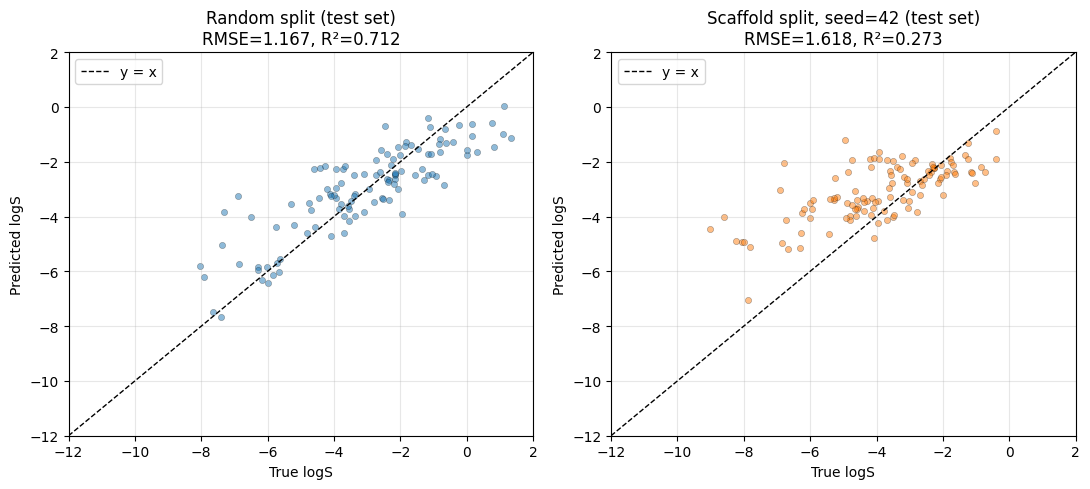

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Random split parity plot ---
yt_r = results_random['test']['y_true']
yp_r = results_random['test']['y_pred']
axes[0].scatter(yt_r, yp_r, alpha=0.5, s=20, edgecolor='k', linewidth=0.3)
lim = [-12, 2]
axes[0].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('True logS')
axes[0].set_ylabel('Predicted logS')
axes[0].set_title(
    f"Random split (test set)\n"
    f"RMSE={results_random['test']['RMSE']:.3f}, "
    f"R²={results_random['test']['R2']:.3f}"
)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper left')

# --- Scaffold split (seed=42) parity plot ---
yt_s = results_p1b['test']['y_true']
yp_s = results_p1b['test']['y_pred']
axes[1].scatter(yt_s, yp_s, alpha=0.5, s=20, edgecolor='k', linewidth=0.3, color='tab:orange')
axes[1].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('True logS')
axes[1].set_ylabel('Predicted logS')
axes[1].set_title(
    f"Scaffold split, seed=42 (test set)\n"
    f"RMSE={results_p1b['test']['RMSE']:.3f}, "
    f"R²={results_p1b['test']['R2']:.3f}"
)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()